# Assignment Machine Learning 2026 - FinGuard Analytics and the Consumer Complaints Challenge

**Student number: 75628**

This notebook presents a full end-to-end response to the Meridian Financial Group complaint-escalation brief using the CFPB complaints dataset. It is structured to address the assignment in sequence: exploratory testing of the executives' assumptions, development and tuning of two predictive models for `Consumer disputed?` (`Yes=1`), evaluation against business and regulatory risk, preparation of deployable artefacts, and interpretation of the main escalation drivers.

### Assignment Setup

First we loads the packages, reusable feature-engineering components, and global settings used throughout the assignment. This setup supports the exploratory analysis in Question 1, predictive modelling and evaluation in Questions 2 and 3, deployment artefacts in Question 4, and model interpretation in Question 5 while keeping the workflow reproducible.


In [6]:
import warnings
warnings.filterwarnings('ignore')

import math
from pathlib import Path
from zipfile import ZipFile, ZIP_DEFLATED

import joblib
import pickle
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier
import shap

from feature_engineering import (
    ComplaintFeatureEngineer,
    ComplaintFeatureEngineerV5,
    PrefitThresholdClassifier,
    ScoreThresholdClassifier,
    positive_class_scores,
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid')


### Data Loading and Cleaning

Next we import the training dataset and the external validation file named in the assignment brief, check their structure, and applies the initial cleaning logic used throughout the notebook. It also constructs the binary target, derives the digital-channel flag used in Question 1, and creates the train-validation split required for the predictive modelling tasks in later questions.


In [7]:
df_train_raw = pd.read_csv('complaints_training.csv')
df_ext_raw = pd.read_csv('complaints_modeltesting100.csv')

# -----------------------------
# Data inspection (before cleaning)
# -----------------------------
print('Raw train shape:', df_train_raw.shape)
print('Raw external shape:', df_ext_raw.shape)
print('Raw target distribution (train):')
print(df_train_raw['Consumer disputed?'].value_counts(dropna=False))
print('Raw duplicate rows (train):', int(df_train_raw.duplicated().sum()))
if 'Complaint ID' in df_train_raw.columns:
    print('Raw duplicate Complaint ID (train):', int(df_train_raw['Complaint ID'].duplicated().sum()))

US_STATE_CODES = {
    'AL','AK','AZ','AR','CA','CO','CT','DE','DC','FL','GA','HI','ID','IL','IN','IA','KS','KY','LA','ME',
    'MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ','NM','NY','NC','ND','OH','OK','OR','PA','RI',
    'SC','SD','TN','TX','UT','VT','VA','WA','WV','WI','WY','PR','VI','GU','AS','MP'
}


def clean_complaints_df(df: pd.DataFrame, is_training: bool = False) -> pd.DataFrame:
    """Clean complaint data safely for model training/inference."""
    out = df.copy()

    # Standardize column names and text values.
    out.columns = [c.strip() for c in out.columns]
    object_cols = out.select_dtypes(include=['object']).columns.tolist()

    missing_tokens = {
        '', ' ', 'na', 'n/a', 'none', 'null', 'nan',
        'not available', 'not provided', 'unknown'
    }

    for col in object_cols:
        s = out[col]
        s = s.apply(lambda v: v.strip() if isinstance(v, str) else v)
        token_mask = s.astype(str).str.lower().isin(missing_tokens)
        out[col] = s.mask(token_mask, np.nan)

    # Q1-focused canonical cleaning
    if 'Product' in out.columns:
        out['Product'] = out['Product'].apply(lambda v: v.strip() if isinstance(v, str) else v)

    if 'Submitted via' in out.columns:
        submitted_map = {
            'web': 'Web',
            'email': 'Email',
            'fax': 'Fax',
            'phone': 'Phone',
            'referral': 'Referral',
            'postal mail': 'Postal mail',
        }
        s = out['Submitted via'].apply(lambda v: v.strip() if isinstance(v, str) else v)
        out['Submitted via'] = s.apply(lambda v: submitted_map.get(v.lower(), v) if isinstance(v, str) else v)

    if 'State' in out.columns:
        state = out['State'].apply(lambda v: v.strip().upper() if isinstance(v, str) else v)
        state = state.where(state.isin(US_STATE_CODES), np.nan)
        out['State'] = state.fillna('Unknown')

    if 'Timely response?' in out.columns:
        timely_map = {'yes': 'Yes', 'no': 'No'}
        t = out['Timely response?'].apply(lambda v: v.strip().lower() if isinstance(v, str) else v)
        out['Timely response?'] = t.map(timely_map)

    # Normalize ZIP code to 5-digit token when possible; else keep missing.
    if 'ZIP code' in out.columns:
        zip5 = out['ZIP code'].astype(str).str.extract(r'(\d{5})', expand=False)
        zip5 = zip5.where(zip5.notna(), np.nan)
        out['ZIP code'] = zip5

    # Parse date columns; keep canonical yyyy-mm-dd strings for reproducibility.
    for dc in ['Date received', 'Date sent to company']:
        if dc in out.columns:
            dt = pd.to_datetime(out[dc], errors='coerce')
            out[dc] = dt.dt.strftime('%Y-%m-%d')
            out.loc[dt.isna(), dc] = np.nan

    # Defensive dedupe.
    out = out.drop_duplicates()
    if 'Complaint ID' in out.columns:
        out = out.drop_duplicates(subset=['Complaint ID'], keep='first')

    # Robust target mapping for training.
    if is_training:
        if 'Consumer disputed?' not in out.columns:
            raise ValueError("Training data must contain 'Consumer disputed?' column")

        target_clean = out['Consumer disputed?'].astype(str).str.strip().str.lower()
        out['target'] = target_clean.map({'yes': 1, 'no': 0})
        out = out[out['target'].isin([0, 1])].copy()
        out['target'] = out['target'].astype(int)

    return out


# Apply cleaning
df_model = clean_complaints_df(df_train_raw, is_training=True)
df_ext = clean_complaints_df(df_ext_raw, is_training=False)

# Derived analysis feature for Q1
digital_channels = {'Web', 'Email', 'Fax'}
if 'Submitted via' in df_model.columns:
    df_model['is_digital_channel'] = df_model['Submitted via'].isin(digital_channels).astype(int)
else:
    df_model['is_digital_channel'] = 0

print('After cleaning:')
print('Modeling rows:', df_model.shape)
print('External rows:', df_ext.shape)
print('Class balance (target):', df_model['target'].value_counts(normalize=True).to_dict())

q1_cols = ['Product', 'Submitted via', 'State', 'Timely response?']
for c in q1_cols:
    if c in df_model.columns:
        miss_rate = df_model[c].isna().mean()
        print(f"[{c}] missing rate: {miss_rate:.4%}")
        print(df_model[c].value_counts(dropna=False).head(5))

print('Base dispute rate:', round(df_model['target'].mean(), 4))

X = df_model.drop(columns=['Consumer disputed?', 'target'], errors='ignore')
y = df_model['target']

X_dev, X_test, y_dev, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_dev, y_dev, test_size=0.20, stratify=y_dev, random_state=RANDOM_STATE
)

print('Train split:', X_train.shape)
print('Model-selection validation split:', X_val.shape)
print('Untouched test split:', X_test.shape)


Raw train shape: (321430, 18)
Raw external shape: (100, 18)
Raw target distribution (train):
Consumer disputed?
No     257436
Yes     63994
Name: count, dtype: int64
Raw duplicate rows (train): 0
Raw duplicate Complaint ID (train): 0
After cleaning:
Modeling rows: (321430, 20)
External rows: (100, 18)
Class balance (target): {0: 0.8009084404069315, 1: 0.19909155959306848}
[Product] missing rate: 0.0000%
Product
Mortgage                   85296
Debt collection            78794
Credit reporting           63510
Bank account or service    31802
Credit card                31274
Name: count, dtype: int64
[Submitted via] missing rate: 0.0000%
Submitted via
Web            230522
Referral        45158
Postal mail     20743
Phone           20522
Fax              4460
Name: count, dtype: int64
[State] missing rate: 0.0000%
State
CA    45252
FL    30599
TX    26448
NY    21674
GA    13812
Name: count, dtype: int64
[Timely response?] missing rate: 0.0000%
Timely response?
Yes    313061
No       836

## Question 1.1

This section tests the three executive assumptions stated in the assignment brief using the cleaned complaint data. Specifically we, investigate all three executive assumptions with exploratory analysis and quantified evidence:
- Product-level differences in dispute escalation.
- Digital channel complaints escalating more frequently.
- Regional (state-level) differences in response practices and outcomes.

All assumptions are explored with descriptive statistics, association tests, effect-size measures, and visual evidence so the claims can be assessed on data rather than anecdote.


Assumption A: Product differences
                    Product      n  dispute_rate  delta_vs_overall_pp  \
0                  Mortgage  85296      0.236471             3.737908   
1             Consumer Loan  13336      0.226230             2.713819   
2               Credit card  31274      0.213084             1.399279   
3   Bank account or service  31802      0.197032            -0.205993   
4              Student loan   8783      0.194467            -0.462498   
5   Other financial service    428      0.186916            -1.217567   
6           Debt collection  78794      0.184570            -1.452167   
7          Credit reporting  63510      0.163045            -3.604637   
8               Payday loan   3291      0.158614            -4.047716   
9           Money transfers   2788      0.138809            -6.028238   
10             Prepaid card   2120      0.130660            -6.843118   

    lift_vs_overall_pct  
0             18.774821  
1             13.631012  
2          

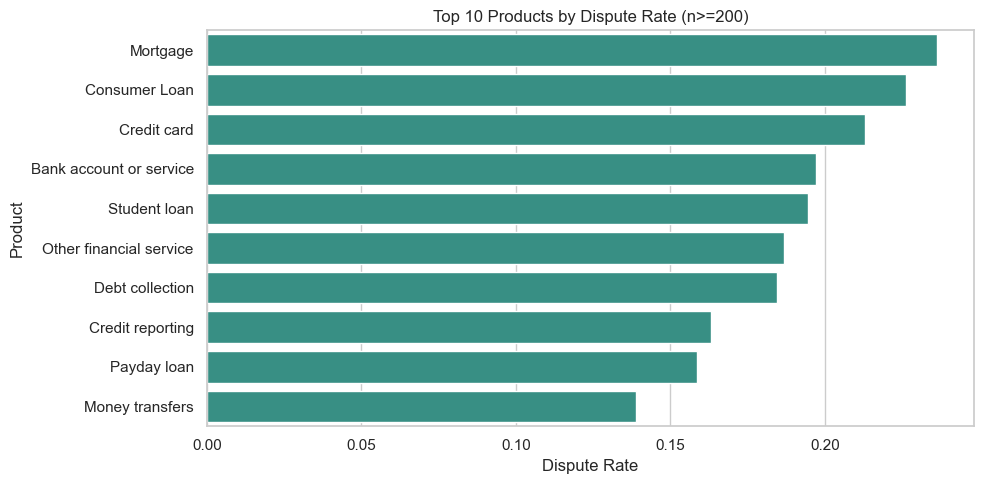


Assumption B: Digital channel differences
  channel_group       n  dispute_rate
0   Non-digital   86423      0.153362
1       Digital  235007      0.215908
Digital rate=0.2159, non-digital rate=0.1534, gap=6.25 pp, lift=40.78%, odds ratio=1.5201, p-value=0.000e+00


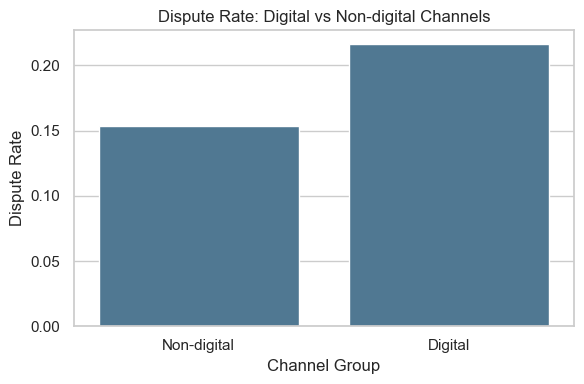


Assumption C: State-level differences in response practices
   State      n  dispute_rate  timely_rate  non_timely_rate
0     MT    529      0.187146     0.958412         0.041588
1     MS   1638      0.231990     0.962759         0.037241
2     NE   1023      0.210166     0.962854         0.037146
3     LA   3371      0.179769     0.964402         0.035598
4     TN   5080      0.195472     0.965551         0.034449
5     VT    527      0.184061     0.965844         0.034156
6     ME   1089      0.243343     0.966024         0.033976
7     ID   1124      0.177046     0.966192         0.033808
8     MO   4244      0.189444     0.967012         0.032988
9     IA   1360      0.165441     0.967647         0.032353
10    OK   2284      0.179510     0.968039         0.031961
11    NM   1629      0.157766     0.968079         0.031921
12    UT   1790      0.193855     0.968156         0.031844
13    NV   4233      0.215923     0.968580         0.031420
14    TX  26448      0.176308     0.970

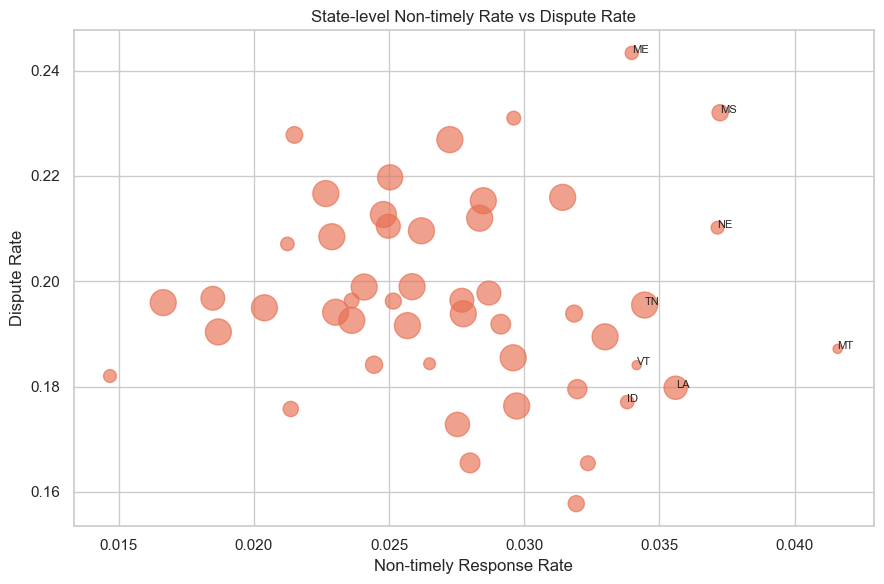


Q1.1 Verdicts


,assumption,verdict,evidence
0,Certain products generate more negative outcomes,Supported,Top-bottom product dispute gap=10.58 pp; p=0.0...
1,Digital complaints escalate more frequently,Supported,Digital vs non-digital gap=6.25 pp; lift=40.78...
2,Regional differences influence response practices,Supported,"State non-timely spread=2.69 pp, dispute sprea..."


In [8]:
ALPHA = 0.05
MIN_N_PRODUCT = 200
MIN_N_CHANNEL = 200
MIN_N_STATE = 500


def safe_chi2(ct: pd.DataFrame):
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan, np.nan
    chi2, p_value, _, _ = chi2_contingency(ct)
    return chi2, p_value


def cramers_v_from_crosstab(ct: pd.DataFrame) -> float:
    if ct.shape[0] < 2 or ct.shape[1] < 2:
        return np.nan
    chi2, _, _, _ = chi2_contingency(ct)
    n = ct.to_numpy().sum()
    if n == 0:
        return np.nan
    r, k = ct.shape
    denom = min(r - 1, k - 1)
    if denom <= 0:
        return np.nan
    return float(np.sqrt((chi2 / n) / denom))


def odds_ratio_2x2(ct: pd.DataFrame) -> float:
    if ct.shape != (2, 2):
        return np.nan
    vals = ct.to_numpy(dtype=float)
    if (vals == 0).any():
        vals = vals + 0.5
    a, b = vals[0, 0], vals[0, 1]
    c, d = vals[1, 0], vals[1, 1]
    return float((a * d) / (b * c))


# -----------------------------
# Assumption A: Product differences in escalation outcomes
# -----------------------------
overall_rate = float(df_model['target'].mean())
product_stats = (
    df_model.groupby('Product', dropna=False)['target']
    .agg(['count', 'mean'])
    .reset_index()
    .rename(columns={'count': 'n', 'mean': 'dispute_rate'})
)
product_stats = product_stats[product_stats['n'] >= MIN_N_PRODUCT].copy()
product_stats['delta_vs_overall_pp'] = (product_stats['dispute_rate'] - overall_rate) * 100
product_stats['lift_vs_overall_pct'] = (product_stats['dispute_rate'] / overall_rate - 1.0) * 100
product_stats = product_stats.sort_values('dispute_rate', ascending=False).reset_index(drop=True)

top_product = product_stats.iloc[0]
bottom_product = product_stats.iloc[-1]
product_gap_pp = float((top_product['dispute_rate'] - bottom_product['dispute_rate']) * 100)

ct_product = pd.crosstab(df_model['Product'], df_model['target'])
_, p_product = safe_chi2(ct_product)
cv_product = cramers_v_from_crosstab(ct_product)

print('Assumption A: Product differences')
print(product_stats.head(15))
print(
    f"Top product={top_product['Product']} ({top_product['dispute_rate']:.4f}), "
    f"bottom product={bottom_product['Product']} ({bottom_product['dispute_rate']:.4f}), "
    f"gap={product_gap_pp:.2f} pp, p-value={p_product:.3e}, Cramer's V={cv_product:.4f}"
)

plt.figure(figsize=(10, 5))
plot_products = product_stats.head(10)
sns.barplot(data=plot_products, x='dispute_rate', y='Product', color='#2a9d8f')
plt.title('Top 10 Products by Dispute Rate (n>=200)')
plt.xlabel('Dispute Rate')
plt.ylabel('Product')
plt.tight_layout()
plt.show()


# -----------------------------
# Assumption B: Digital channels escalate more frequently
# -----------------------------
channel_stats_binary = (
    df_model.groupby('is_digital_channel')['target']
    .agg(['count', 'mean'])
    .reset_index()
    .rename(columns={'count': 'n', 'mean': 'dispute_rate'})
)
channel_stats_binary['channel_group'] = channel_stats_binary['is_digital_channel'].map({1: 'Digital', 0: 'Non-digital'})
channel_stats_binary = channel_stats_binary[channel_stats_binary['n'] >= MIN_N_CHANNEL].copy()

ct_channel = pd.crosstab(df_model['is_digital_channel'], df_model['target'])
_, p_channel = safe_chi2(ct_channel)
or_channel = odds_ratio_2x2(ct_channel)

digital_rate = float(channel_stats_binary.loc[channel_stats_binary['is_digital_channel'] == 1, 'dispute_rate'].iloc[0])
non_digital_rate = float(channel_stats_binary.loc[channel_stats_binary['is_digital_channel'] == 0, 'dispute_rate'].iloc[0])
digital_gap_pp = (digital_rate - non_digital_rate) * 100
digital_lift_pct = (digital_rate / non_digital_rate - 1.0) * 100

print()
print('Assumption B: Digital channel differences')
print(channel_stats_binary[['channel_group', 'n', 'dispute_rate']])
print(
    f"Digital rate={digital_rate:.4f}, non-digital rate={non_digital_rate:.4f}, "
    f"gap={digital_gap_pp:.2f} pp, lift={digital_lift_pct:.2f}%, "
    f"odds ratio={or_channel:.4f}, p-value={p_channel:.3e}"
)

plt.figure(figsize=(6, 4))
sns.barplot(data=channel_stats_binary, x='channel_group', y='dispute_rate', color='#457b9d')
plt.title('Dispute Rate: Digital vs Non-digital Channels')
plt.xlabel('Channel Group')
plt.ylabel('Dispute Rate')
plt.tight_layout()
plt.show()


# -----------------------------
# Assumption C: State-level differences influence response practices
# -----------------------------
q1_state = df_model.copy()
q1_state['timely_binary'] = q1_state['Timely response?'].map({'Yes': 1, 'No': 0})

state_stats = (
    q1_state.groupby('State', dropna=False)
    .agg(
        n=('target', 'size'),
        dispute_rate=('target', 'mean'),
        timely_rate=('timely_binary', 'mean'),
    )
    .reset_index()
)
state_stats['non_timely_rate'] = 1 - state_stats['timely_rate']

state_stats_filtered = state_stats[state_stats['n'] >= MIN_N_STATE].copy()
if state_stats_filtered.empty:
    print('No states met MIN_N_STATE=500; using fallback MIN_N_STATE=300')
    state_stats_filtered = state_stats[state_stats['n'] >= 300].copy()

valid_states = set(state_stats_filtered['State'])
state_subset = q1_state[q1_state['State'].isin(valid_states)].copy()

ct_state_target = pd.crosstab(state_subset['State'], state_subset['target'])
_, p_state_target = safe_chi2(ct_state_target)
cv_state_target = cramers_v_from_crosstab(ct_state_target)

state_timely_subset = state_subset[state_subset['Timely response?'].isin(['Yes', 'No'])].copy()
ct_state_timely = pd.crosstab(state_timely_subset['State'], state_timely_subset['Timely response?'])
_, p_state_timely = safe_chi2(ct_state_timely)
cv_state_timely = cramers_v_from_crosstab(ct_state_timely)

state_stats_filtered = state_stats_filtered.sort_values('non_timely_rate', ascending=False).reset_index(drop=True)
state_non_timely_spread_pp = float((state_stats_filtered['non_timely_rate'].max() - state_stats_filtered['non_timely_rate'].min()) * 100)
state_dispute_spread_pp = float((state_stats_filtered['dispute_rate'].max() - state_stats_filtered['dispute_rate'].min()) * 100)

print()
print('Assumption C: State-level differences in response practices')
print(state_stats_filtered.head(15))
print(
    f"State non-timely spread={state_non_timely_spread_pp:.2f} pp, "
    f"state dispute spread={state_dispute_spread_pp:.2f} pp, "
    f"p(State x target)={p_state_target:.3e}, Cramer's V target={cv_state_target:.4f}, "
    f"p(State x timely)={p_state_timely:.3e}, Cramer's V timely={cv_state_timely:.4f}"
)

plot_state = state_stats_filtered.dropna(subset=['non_timely_rate', 'dispute_rate']).copy()
plt.figure(figsize=(9, 6))
plt.scatter(
    plot_state['non_timely_rate'],
    plot_state['dispute_rate'],
    s=np.clip(plot_state['n'] / 12, 20, 350),
    alpha=0.65,
    color='#e76f51',
)
plt.title('State-level Non-timely Rate vs Dispute Rate')
plt.xlabel('Non-timely Response Rate')
plt.ylabel('Dispute Rate')
for _, r in plot_state.nlargest(8, 'non_timely_rate').iterrows():
    plt.annotate(r['State'], (r['non_timely_rate'], r['dispute_rate']), fontsize=8)
plt.tight_layout()
plt.show()


def verdict(significant: bool, effect_pp: float, min_pp: float = 1.0) -> str:
    if significant and effect_pp >= min_pp:
        return 'Supported'
    if significant:
        return 'Partially supported'
    return 'Not supported'

verdict_a = verdict(pd.notna(p_product) and p_product < ALPHA, product_gap_pp)
verdict_b = verdict(pd.notna(p_channel) and p_channel < ALPHA, abs(digital_gap_pp))
verdict_c = verdict(
    (pd.notna(p_state_target) and p_state_target < ALPHA) or (pd.notna(p_state_timely) and p_state_timely < ALPHA),
    max(state_non_timely_spread_pp, state_dispute_spread_pp),
)

q1_verdicts = pd.DataFrame([
    {
        'assumption': 'Certain products generate more negative outcomes',
        'verdict': verdict_a,
        'evidence': (
            f"Top-bottom product dispute gap={product_gap_pp:.2f} pp; "
            f"p={p_product:.3e}; Cramer's V={cv_product:.4f}"
        ),
    },
    {
        'assumption': 'Digital complaints escalate more frequently',
        'verdict': verdict_b,
        'evidence': (
            f"Digital vs non-digital gap={digital_gap_pp:.2f} pp; lift={digital_lift_pct:.2f}%; "
            f"OR={or_channel:.4f}; p={p_channel:.3e}"
        ),
    },
    {
        'assumption': 'Regional differences influence response practices',
        'verdict': verdict_c,
        'evidence': (
            f"State non-timely spread={state_non_timely_spread_pp:.2f} pp, dispute spread={state_dispute_spread_pp:.2f} pp; "
            f"p(State x target)={p_state_target:.3e}, p(State x timely)={p_state_timely:.3e}"
        ),
    },
])

print()
print('Q1.1 Verdicts')
display(q1_verdicts)



## Question 1.2

Three evidence-backed managerial insights based on Q1.1 findings.


1. Product-targeted escalation playbooks
- Evidence: Mortgage has dispute rate 23.65% vs Prepaid card at 13.07% (gap 10.58 pp).
- Managerial implication: escalation risk is concentrated in specific product lines rather than uniformly distributed.
- Action: assign specialist queues and root-cause remediation for the highest-risk product categories with monthly dispute-rate KPIs.

2. Digital-intake triage controls
- Evidence: digital dispute rate is 21.59% vs non-digital 15.34% (gap 6.25 pp; lift 40.78%; OR 1.52).
- Managerial implication: digital-origin complaints present a meaningfully different risk profile.
- Action: deploy digital-first escalation-monitoring rules and a stricter post-response follow-up SLA for high-risk digital submissions.

3. State-level response governance
- Evidence: state non-timely spread is 2.69 pp and dispute spread is 8.56 pp; highest non-timely state=MT (4.16%).
- Managerial implication: response-practice variability by state is operationally material.
- Action: set state-level escalation governance with threshold alerts for non-timely rate and dispute-rate excursions.

## Question 2.1

This is a **supervised binary classification** problem.

## Question 2.2

First we define the feature sets, preprocessing pipelines, model-builder functions, and threshold-selection helpers needed to implement the predictive task. The modelling timepoint in this notebook is explicitly post-response: prediction is made after the company has issued its response but before the consumer decides whether to dispute it. These design choices therefore convert the complaint-escalation problem into a reproducible binary-classification workflow and create a consistent basis for comparing the selected models, Logistic Regression and XGBoost, in Question 2.2.


In [9]:
numeric_features = ['days_to_company', 'month_received', 'weekday_received', 'narrative_present', 'narrative_len']
cat_features_lr = [
    'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company',
    'State', 'Tags', 'Consumer consent provided?', 'Submitted via',
    'Company response to consumer', 'Timely response?',
]

text_feature_xgb = 'narrative_text'
cat_features_xgb = [
    'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Company', 'State', 'Tags',
    'Consumer consent provided?', 'Submitted via', 'Company response to consumer', 'Timely response?', 'Company public response', 'zip3',
]
numeric_features_xgb = [
    'received_year', 'received_month', 'received_dayofweek', 'received_quarter',
    'days_to_company', 'days_to_company_missing',
    'narrative_present', 'narrative_len_chars', 'narrative_len_words',
    'submitted_via_digital',
]

MIN_PRECISION = 0.20

preprocess_xgb = ColumnTransformer(
    transformers=[
        (
            'text',
            TfidfVectorizer(
                min_df=5,
                max_features=15000,
                ngram_range=(1, 2),
                sublinear_tf=True,
                dtype=np.float32,
            ),
            text_feature_xgb,
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
                ('onehot', OneHotEncoder(
                    handle_unknown='infrequent_if_exist',
                    min_frequency=50,
                    dtype=np.float32,
                )),
            ]),
            cat_features_xgb,
        ),
        (
            'num',
            Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
            ]),
            numeric_features_xgb,
        ),
    ],
    sparse_threshold=1.0,
)


def build_lr(max_features=10000, ngram=(1, 1), C=1.0, penalty='l2', solver='liblinear', max_iter=320):
    pre = ColumnTransformer([
        ('text', TfidfVectorizer(max_features=max_features, ngram_range=ngram, min_df=2), 'text_all'),
        ('num', Pipeline([('imp', SimpleImputer(strategy='median'))]), numeric_features),
        ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')), ('ohe', OneHotEncoder(handle_unknown='ignore'))]), cat_features_lr),
    ])
    clf = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        class_weight='balanced',
        max_iter=max_iter,
        random_state=RANDOM_STATE,
    )
    return Pipeline([
        ('feature_engineering', ComplaintFeatureEngineer()),
        ('preprocess', pre),
        ('model', clf),
    ])


def build_xgb(**params):
    model = XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        tree_method='hist',
        n_jobs=-1,
        random_state=RANDOM_STATE,
        **params,
    )
    return Pipeline([
        ('feature_engineering', ComplaintFeatureEngineerV5()),
        ('preprocess', preprocess_xgb),
        ('model', model),
    ])


def metric_pack(y_true, y_pred):
    return {
        'recall': recall_score(y_true, y_pred, pos_label=1),
        'precision': precision_score(y_true, y_pred, pos_label=1, zero_division=0),
        'f1': f1_score(y_true, y_pred, pos_label=1, zero_division=0),
        'cm': confusion_matrix(y_true, y_pred),
    }


def evaluate_thresholds(y_true, proba):
    rows = []
    thresholds = np.round(np.arange(0.05, 0.951, 0.01), 2)
    for thr in thresholds:
        pred = (proba >= thr).astype(int)
        rows.append({
            'threshold': float(thr),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'f1': f1_score(y_true, pred, zero_division=0),
        })
    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.sort_values(
        ['f1', 'precision', 'recall', 'threshold'],
        ascending=[False, False, False, True],
    ).iloc[0]
    return threshold_df, best_row


def best_threshold(y_true, scores, min_precision=MIN_PRECISION):
    threshold_df, best_row = evaluate_thresholds(y_true, scores)
    ok = threshold_df[threshold_df['precision'] >= min_precision]
    if not ok.empty:
        row = ok.sort_values(['f1', 'precision', 'recall', 'threshold'], ascending=[False, False, False, True]).iloc[0]
    else:
        row = best_row
    return threshold_df, float(row['threshold'])


Use of `Logistic Regression` and `XGBoost` is appropriate because Meridian is trying to predict whether a complaint will escalate into a disputed outcome using a dataset that combines structured operational fields, categorical information, complaint text, and post-response process variables. The modelling timepoint is after the company response has been issued but before the consumer decides whether to dispute it, so response-stage fields such as response category, timeliness, and elapsed handling time are intentionally treated as valid predictors rather than leakage. This remains a supervised binary classification problem with clear business consequences: missed high-risk complaints increase regulatory and reputational risk, while too many false alarms create unnecessary review workload.

`Logistic Regression` is appropriate because it provides a strong, transparent baseline. It works very well with sparse representations such as TF-IDF text features and one-hot encoded categories, which are central to this complaint dataset. It is computationally efficient, easy to reproduce, and easier to explain to non-technical stakeholders and governance audiences. In a regulated business setting, that interpretability matters: Logistic Regression gives a clear benchmark for whether escalation risk can already be predicted using a relatively simple and defensible linear model.

`XGBoost` is appropriate because complaint escalation is unlikely to be driven only by simple linear effects. In this dataset, risk may emerge from interactions between product type, submission channel, complaint narrative, response category, timeliness, and geography. XGBoost is designed to capture these non-linear relationships and interaction effects more effectively than a linear classifier. It is also robust on heterogeneous tabular data, handles complex decision boundaries well, and often delivers stronger predictive performance when business processes generate subtle patterns that are not additive.

Using both models is valuable because they represent two different modelling philosophies. Logistic Regression provides the interpretable benchmark; XGBoost provides the higher-capacity alternative. This makes the final recommendation more defensible: if XGBoost outperforms Logistic Regression meaningfully, then the added model complexity is justified by measurable operational benefit. If it does not, then the simpler model remains preferable.

Including a `simple` and a `tuned` version of each model is also important. The simple version establishes a baseline and shows how well the method performs under straightforward settings, which helps demonstrate that any later improvement is real rather than assumed. It also acts as a sanity check on the feature pipeline and gives the marker a clean reference point.

The tuned version shows that the model has been properly optimized for the business objective rather than left at generic defaults. For Logistic Regression, tuning can improve the balance between bias and variance through choices such as regularisation strength and penalty. For XGBoost, tuning is even more important because parameters such as tree depth, learning rate, regularisation, subsampling, and class-weighting directly affect recall, precision, and overfitting. In business terms, tuning helps align the model with Meridian’s operational goal: identifying as many genuinely high-risk complaints as possible without creating an unmanageable intervention queue.

In short, the combination of `simple` and `tuned` versions for both `Logistic Regression` and `XGBoost` demonstrates rigour. It shows baseline performance, improvement from optimization, and a credible comparison between an interpretable model and a more powerful non-linear model, which is exactly the kind of evidence-based modelling approach this assignment is asking for.

### Model Training and Tuning

Next we fit the candidate models required for Question 2.2: a baseline and tuned Logistic Regression model plus baseline and tuned XGBoost variants. Cross-validation and targeted hyperparameter search are used here to produce defensible candidate pipelines before they are compared on the held-out validation split.


In [10]:
cv_main = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

idx_lr = y_train.sample(n=min(70000, len(y_train)), random_state=RANDOM_STATE).index
X_lr, y_lr = X_train.loc[idx_lr], y_train.loc[idx_lr]

idx_xgb = y_train.sample(n=min(40000, len(y_train)), random_state=RANDOM_STATE + 1).index
X_xgb, y_xgb = X_train.loc[idx_xgb], y_train.loc[idx_xgb]

neg_count = int((y_train == 0).sum())
pos_count = int((y_train == 1).sum())
base_scale_pos_weight = neg_count / max(pos_count, 1)

candidate_specs = [
    {
        'model': 'LR_Simple',
        'family': 'LogisticRegression',
        'builder': build_lr,
        'params': {
            'max_features': 10000,
            'ngram': (1, 1),
            'C': 1.0,
            'penalty': 'l2',
            'solver': 'liblinear',
            'max_iter': 320,
        },
        'cv_mean_f1': np.nan,
        'cv_std_f1': np.nan,
    },
    {
        'model': 'XGB_Basic',
        'family': 'XGB',
        'builder': build_xgb,
        'params': {},
        'cv_mean_f1': np.nan,
        'cv_std_f1': np.nan,
    },
]

lr_base = build_lr(max_features=12000, ngram=(1, 1), C=1.0, penalty='l2', solver='liblinear', max_iter=350)
grid_lr = {
    'preprocess__text__max_features': [10000, 12000],
    'model__C': [0.3, 0.5, 1.0, 2.0],
    'model__penalty': ['l1', 'l2'],
    'model__solver': ['liblinear'],
    'model__max_iter': [350],
}
search_lr = GridSearchCV(lr_base, grid_lr, scoring='f1', cv=cv_main, n_jobs=-1, verbose=1)
search_lr.fit(X_lr, y_lr)

candidate_specs.append({
    'model': 'LR_Tuned',
    'family': 'LogisticRegression',
    'builder': build_lr,
    'params': {
        'max_features': search_lr.best_params_['preprocess__text__max_features'],
        'ngram': (1, 1),
        'C': search_lr.best_params_['model__C'],
        'penalty': search_lr.best_params_['model__penalty'],
        'solver': search_lr.best_params_['model__solver'],
        'max_iter': search_lr.best_params_['model__max_iter'],
    },
    'cv_mean_f1': search_lr.best_score_,
    'cv_std_f1': search_lr.cv_results_['std_test_score'][search_lr.best_index_],
})

xgb_param_dist = {
    'model__n_estimators': [150, 250, 350],
    'model__max_depth': [4, 6, 8],
    'model__learning_rate': [0.03, 0.05, 0.08, 0.12],
    'model__min_child_weight': [1, 4, 8],
    'model__subsample': [0.70, 0.85, 1.00],
    'model__colsample_bytree': [0.70, 0.85, 1.00],
    'model__gamma': [0.00, 0.10, 0.20],
    'model__reg_alpha': [0.00, 0.10, 0.30],
    'model__reg_lambda': [1.00, 1.50, 2.00],
    'model__scale_pos_weight': [round(base_scale_pos_weight * m, 3) for m in (0.75, 1.00, 1.25)],
}
search_xgb = RandomizedSearchCV(
    estimator=build_xgb(),
    param_distributions=xgb_param_dist,
    n_iter=12,
    scoring='f1',
    cv=cv_main,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
)
search_xgb.fit(X_xgb, y_xgb)

best_xgb_params = {k.replace('model__', ''): v for k, v in search_xgb.best_params_.items()}

candidate_specs.append({
    'model': 'XGB_Tuned',
    'family': 'XGB',
    'builder': build_xgb,
    'params': best_xgb_params,
    'cv_mean_f1': search_xgb.best_score_,
    'cv_std_f1': search_xgb.cv_results_['std_test_score'][search_xgb.best_index_],
})

candidate_models = []
for spec in candidate_specs:
    pipe = spec['builder'](**spec['params'])
    pipe.fit(X_train, y_train)
    candidate_models.append({
        'model': spec['model'],
        'family': spec['family'],
        'pipeline': pipe,
        'cv_mean_f1': spec['cv_mean_f1'],
        'cv_std_f1': spec['cv_std_f1'],
    })

print('LR tuned best params:', search_lr.best_params_)
print('XGB tuned best params:', search_xgb.best_params_)
print('Final candidate models:', [item['model'] for item in candidate_models])


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Fitting 3 folds for each of 12 candidates, totalling 36 fits
LR tuned best params: {'model__C': 0.5, 'model__max_iter': 350, 'model__penalty': 'l1', 'model__solver': 'liblinear', 'preprocess__text__max_features': 12000}
XGB tuned best params: {'model__subsample': 0.85, 'model__scale_pos_weight': 4.023, 'model__reg_lambda': 1.5, 'model__reg_alpha': 0.3, 'model__n_estimators': 250, 'model__min_child_weight': 4, 'model__max_depth': 4, 'model__learning_rate': 0.03, 'model__gamma': 0.2, 'model__colsample_bytree': 0.85}
Final candidate models: ['LR_Simple', 'XGB_Basic', 'LR_Tuned', 'XGB_Tuned']


### Validation-Based Model Selection

Next each trained candidate is applied to the model-selection validation split to choose a decision threshold and nominate the operationally preferred model. Final performance is then reported on an untouched test split so the deployment recommendation is based on held-out evidence rather than the same data used for threshold selection.


In [11]:
validation_rows = []
threshold_tables = {}
threshold_lookup = {}

for item in candidate_models:
    name = item['model']
    pipe = item['pipeline']

    val_scores = positive_class_scores(pipe, X_val)
    tdf, thr = best_threshold(y_val, val_scores, min_precision=MIN_PRECISION)
    val_pred = (val_scores >= thr).astype(int)
    m_val = metric_pack(y_val, val_pred)

    threshold_tables[name] = tdf
    threshold_lookup[name] = float(thr)
    validation_rows.append({
        'model': name,
        'family': item['family'],
        'cv_mean_f1': item['cv_mean_f1'],
        'cv_std_f1': item['cv_std_f1'],
        'threshold_selected': float(thr),
        'recall_val': m_val['recall'],
        'precision_val': m_val['precision'],
        'f1_val': m_val['f1'],
    })

validation_selection_df = (
    pd.DataFrame(validation_rows)
    .sort_values(['recall_val', 'precision_val', 'f1_val', 'cv_mean_f1'], ascending=False)
    .reset_index(drop=True)
)

display(
    validation_selection_df.round({
        'cv_mean_f1': 4,
        'cv_std_f1': 4,
        'threshold_selected': 4,
        'recall_val': 4,
        'precision_val': 4,
        'f1_val': 4,
    })
)

selected_row = validation_selection_df.iloc[0]
selected_model_name = selected_row['model']
selected_threshold = float(selected_row['threshold_selected'])
selected_pipeline = next(item['pipeline'] for item in candidate_models if item['model'] == selected_model_name)

operational_selected_row = selected_row
operational_selected_model_name = selected_model_name
operational_selected_threshold = selected_threshold
operational_selected_pipeline = selected_pipeline

print('Operational model selected on validation:', operational_selected_model_name)
print('Locked threshold:', round(operational_selected_threshold, 4))
display(threshold_tables[operational_selected_model_name])


,model,family,cv_mean_f1,cv_std_f1,threshold_selected,recall_val,precision_val,f1_val
0,LR_Simple,LogisticRegression,NaN,NaN,0.45,0.7553,0.2542,0.3804
1,XGB_Basic,XGB,NaN,NaN,0.19,0.7217,0.2564,0.3784
2,XGB_Tuned,XGB,0.3673,0.0027,0.51,0.6849,0.2603,0.3772
3,LR_Tuned,LogisticRegression,0.3731,0.0011,0.49,0.6794,0.2660,0.3823


Operational model selected on validation: LR_Simple
Locked threshold: 0.45


,threshold,precision,recall,f1
0,0.05,0.199895,1.000000,0.333187
1,0.06,0.199930,0.999707,0.333219
2,0.07,0.200051,0.999707,0.333388
3,0.08,0.200196,0.999707,0.333589
4,0.09,0.200294,0.999121,0.333692
...,...,...,...,...
86,0.91,0.702703,0.002539,0.005060
87,0.92,0.750000,0.002344,0.004673
88,0.93,0.760000,0.001856,0.003702
89,0.94,0.764706,0.001270,0.002535


## Question 3.1

We then translate the shortlisted models into operational evaluation terms by reporting recall, precision, F1, false negatives, false positives, and flagged workload at the selected threshold for each candidate. These metrics are used because the assignment context prioritises identification of disputed complaints without creating an unmanageable specialist review queue.

For operational use, no single metric is sufficient on its own. Meridian should evaluate complaint-escalation models primarily with **recall** for disputed complaints, while using **precision** and **F1-score** as supporting metrics. This combination is the most appropriate because the model is not just a statistical exercise: it will influence which complaints are escalated early, which customers receive intervention, and how limited review capacity is allocated.

**Recall** should be the primary metric because a false negative is the most costly operational mistake in this context. If a complaint that is genuinely likely to be disputed is not flagged, Meridian may miss the opportunity to intervene early, which increases the risk of complaint deterioration, repeated contact, customer dissatisfaction, and avoidable escalation. In practical terms, high recall means the model is better at surfacing the risky complaints that executives most want to detect.

**Precision** remains essential because a model with high recall but very low precision would overwhelm operational teams with false alarms. If too many complaints are flagged unnecessarily, specialist queues become inefficient, analysts spend time on lower-risk cases, and the business loses the practical value of the model. Precision therefore acts as a workload control metric: it shows whether the flagged complaints are sufficiently concentrated in genuinely high-risk cases.

**F1-score** is useful as a balanced summary metric because it combines recall and precision into a single measure. This is helpful when comparing models that have similar overall behaviour but differ slightly in how aggressively they identify disputed complaints. A strong F1-score indicates that the model is not achieving recall at the cost of excessive false positives, nor achieving precision by missing too many true disputes.


In [12]:
test_rows = []
confusion_lookup = {}

for item in candidate_models:
    name = item['model']
    pipe = item['pipeline']
    thr = threshold_lookup[name]

    test_scores = positive_class_scores(pipe, X_test)
    test_pred = (test_scores >= thr).astype(int)
    m_test = metric_pack(y_test, test_pred)
    confusion_lookup[name] = m_test['cm']
    tn, fp, fn, tp = m_test['cm'].ravel()

    test_rows.append({
        'model': name,
        'family': item['family'],
        'threshold_locked_from_val': thr,
        'recall_test': m_test['recall'],
        'precision_test': m_test['precision'],
        'f1_test': m_test['f1'],
        'fn': fn,
        'fp': fp,
        'flagged_rate_test': float(test_pred.mean()),
        'cv_mean_f1': item['cv_mean_f1'],
    })

test_report_df = (
    pd.DataFrame(test_rows)
    .sort_values(['recall_test', 'precision_test', 'f1_test', 'cv_mean_f1'], ascending=False)
    .reset_index(drop=True)
)

display(
    test_report_df[
        ['model', 'family', 'threshold_locked_from_val', 'recall_test', 'precision_test', 'f1_test', 'fn', 'fp', 'flagged_rate_test']
    ].round({
        'threshold_locked_from_val': 4,
        'recall_test': 4,
        'precision_test': 4,
        'f1_test': 4,
        'flagged_rate_test': 4,
    })
)

selected_test_row = test_report_df.set_index('model').loc[operational_selected_model_name]
selected_cm = confusion_lookup[operational_selected_model_name]
tn, fp, fn, tp = selected_cm.ravel()

operational_selected_df = pd.DataFrame(
    [[tn, fp], [fn, tp]],
    index=['Actual Not Disputed', 'Actual Disputed'],
    columns=['Predicted Not Disputed', 'Predicted Disputed']
)

print('Untouched test performance for selected model:', operational_selected_model_name)
print('Recall:', round(float(selected_test_row['recall_test']), 4))
print('Precision:', round(float(selected_test_row['precision_test']), 4))
print('F1:', round(float(selected_test_row['f1_test']), 4))
display(operational_selected_df)


,model,family,threshold_locked_from_val,recall_test,precision_test,f1_test,fn,fp,flagged_rate_test
0,LR_Simple,LogisticRegression,0.45,0.7509,0.2529,0.3784,3188,28394,0.5912
1,XGB_Basic,XGB,0.19,0.7299,0.2568,0.3800,3457,27033,0.5658
2,XGB_Tuned,XGB,0.51,0.6821,0.2589,0.3753,4069,24990,0.5245
3,LR_Tuned,LogisticRegression,0.49,0.6762,0.2634,0.3791,4144,24205,0.5112


Untouched test performance for selected model: LR_Simple
Recall: 0.7509
Precision: 0.2529
F1: 0.3784


,Predicted Not Disputed,Predicted Disputed
Actual Not Disputed,23093,28394
Actual Disputed,3188,9611


## Question 3.2

The model comparison should be interpreted in two stages. First, the validation split is used to lock a threshold and select the operational candidate under a recall-first decision rule. Second, the untouched test split is used to report the final performance of that selected model. This separation makes the deployment recommendation more defensible because the final metrics are not taken from the same sample used to tune the operating threshold.

In practical terms, the preferred model is the one reported in the outputs above for the held-out test evaluation. The key trade-off remains the same: higher recall reduces the number of missed escalations, while precision and flagged workload indicate how much operational review capacity the business must commit. Meridian should therefore treat the selected threshold as a business operating point rather than a fixed universal constant, and revisit it if review capacity or regulatory priorities change.


## Question 4

The next code cell retrains the held-out best-F1 solution on the full labelled dataset and serialises the required deployment artefacts. This keeps the Question 4 export decision separate from the Question 3 operational recommendation, while still producing the main pipeline pickle and matching split artifacts needed for reproducibility.


In [13]:
# Export final pipeline and matching split artifacts for the best-F1 Question 4 model
export_row = (
    test_report_df
    .sort_values(['f1_test', 'precision_test', 'recall_test', 'cv_mean_f1'], ascending=False)
    .iloc[0]
)
export_model_name = export_row['model']
export_threshold = float(threshold_lookup[export_model_name])
export_pipeline = next(item['pipeline'] for item in candidate_models if item['model'] == export_model_name)

best_pipeline_full = clone(export_pipeline)
final_model = ScoreThresholdClassifier(estimator=best_pipeline_full, threshold=export_threshold)
final_model.fit(X, y)
with open('75628_Pipeline.pkl', 'wb') as f:
    pickle.dump(final_model, f)
print('Saved: 75628_Pipeline.pkl')

fitted_pipeline = final_model.estimator_
preproc_only = Pipeline(fitted_pipeline.steps[:-1])
split_model = PrefitThresholdClassifier(
    estimator=fitted_pipeline.named_steps['model'],
    threshold=export_threshold,
)
with open('75628_Preprocessor.pkl', 'wb') as f:
    pickle.dump(preproc_only, f)
with open('75628_Model.pkl', 'wb') as f:
    pickle.dump(split_model, f)
print('Saved split artifacts: 75628_Preprocessor.pkl and 75628_Model.pkl')


Saved: 75628_Pipeline.pkl
Saved split artifacts: 75628_Preprocessor.pkl and 75628_Model.pkl


### Submission Packaging

This cell assembles the notebook and required artefacts into the submission zip named to match the assignment instructions. This step connects the analytical work to the deliverable that will be assessed for completeness, portability, and reproducibility.


In [14]:
# Create ZIP with exact required artifacts (fail fast if anything is missing)
notebook_file = '75628_Complaints_Notebook.ipynb'
files_to_zip = [
    notebook_file,
    '75628_Pipeline.pkl',
    '75628_Preprocessor.pkl',
    '75628_Model.pkl',
    '75628_requirements.txt',
    'feature_engineering.py',
    '75628_ModelReload_Test.ipynb',
]
zip_name = '75628_Complaints_Assignment.zip'
missing_files = [fn for fn in files_to_zip if not Path(fn).exists()]
if missing_files:
    raise FileNotFoundError(f'Missing required handover files: {missing_files}')

with ZipFile(zip_name, 'w', compression=ZIP_DEFLATED) as zf:
    for fn in files_to_zip:
        zf.write(fn)

print(f'Created {zip_name} with {len(files_to_zip)} files.')


Created 75628_Complaints_Assignment.zip with 7 files.


## Question 5

Predictive accuracy alone is not enough for Meridian's leadership team. To act on the model, they need to understand which factors are most strongly associated with complaint escalation and whether those signals make business sense. For that reason, the next step applies **SHAP** (`SHapley Additive exPlanations`) to the recommended model on a sample of the held-out test data.

SHAP is a model-interpretation method that estimates how much each feature contributes to a prediction. In this context, it helps explain which product, issue, channel, timing, response, and narrative features are pushing predicted escalation risk upward or downward. Because the modelling timepoint is post-response, these explanations should be read as showing what drives dispute risk after Meridian has already responded but before the consumer decides whether to dispute that response.

Using SHAP in this project strengthens the analysis in three ways. First, it provides evidence about the factors the model is relying on, rather than treating the model as a black box. Second, it allows the modelling results to be connected back to the exploratory findings from Question 1, which improves credibility and managerial usefulness. Third, it supports a realistic recommendation for reducing escalation risk, improving customer experience, and strengthening regulatory compliance through better post-response case management. The SHAP results should therefore be interpreted as showing the features most strongly associated with escalation in the model, rather than proving direct causation.


In [15]:
# SHAP driver analysis on sampled held-out test data

SHAP_SAMPLE = 400
sample_idx = y_test.sample(n=min(SHAP_SAMPLE, len(y_test)), random_state=42).index
X_sample = X_test.loc[sample_idx].copy()

pipe = operational_selected_pipeline
fe = pipe.named_steps['feature_engineering']
pre = pipe.named_steps['preprocess']
model_core = pipe.named_steps['model']

X_fe = fe.transform(X_sample)
X_mat = pre.transform(X_fe)
feature_names = list(pre.get_feature_names_out())

if hasattr(model_core, 'get_booster'):
    explainer = shap.TreeExplainer(model_core)
    shap_values = explainer.shap_values(X_mat)
elif hasattr(model_core, 'coef_'):
    explainer = shap.LinearExplainer(model_core, X_mat)
    shap_values = explainer.shap_values(X_mat)
else:
    explainer = shap.Explainer(model_core.predict_proba, X_mat)
    shap_values = explainer(X_mat).values

if isinstance(shap_values, list):
    shap_matrix = shap_values[1]
else:
    shap_matrix = shap_values

mean_abs_shap = np.mean(np.abs(shap_matrix), axis=0)
shap_importance = (
    pd.DataFrame({'feature': feature_names, 'mean_abs_shap': mean_abs_shap})
    .sort_values('mean_abs_shap', ascending=False)
    .head(20)
)
display(shap_importance)


,feature,mean_abs_shap
13200,cat__Company response to consumer_Closed with ...,0.400655
10011,cat__Product_Mortgage,0.162801
10003,num__narrative_present,0.160379
10119,"cat__Issue_Loan modification,collection,forecl...",0.149124
13197,cat__Submitted via_Referral,0.087618
13202,cat__Company response to consumer_Closed with ...,0.084892
1846,text__chooses,0.082715
6983,text__provide,0.081728
10120,"cat__Issue_Loan servicing, payments, escrow ac...",0.078952
10007,cat__Product_Credit card,0.072116


## Interpretation

Based on the model interpretation, the factors that most strongly influence complaint escalation are concentrated in four areas. First, company response categories are the dominant signals in the SHAP ranking, with multiple `Company response to consumer` levels appearing at the top of the table. This indicates that, at the post-response modelling timepoint used in this notebook, the way a complaint is closed or explained is strongly associated with whether the consumer later disputes the outcome.

Second, mortgage-related complaint types remain highly influential. `Product = Mortgage`, `Issue = Loan modification, collection, foreclosure`, `Issue = Loan servicing, payments, escrow account`, and `Sub-product = Conventional fixed mortgage` all rank highly. This shows that dispute risk is concentrated in complex mortgage-servicing complaints rather than being evenly distributed across all products, which is consistent with Q1 where Mortgage had the highest dispute rate at 23.65% compared with 13.07% for Prepaid card.

Third, complaint detail and intake route matter. `narrative_present`, `narrative_len`, narrative terms such as `chooses`, `provide`, and `public`, plus `Submitted via = Referral` and `Submitted via = Web`, appear among the strongest predictors. This suggests that more fully documented complaints and digitally submitted or referred cases follow distinct post-response escalation patterns.

Fourth, additional structured signals such as `Product = Credit card`, `Product = Credit reporting`, `Sub-issue = Debt is not mine`, and consumer-consent indicators also contribute useful predictive information. Taken together, the model suggests that post-response dispute risk is shaped by a combination of response outcome, complaint type, complaint detail, and intake route rather than by any single factor alone.

A realistic strategic action is to implement a post-response dispute-risk review workflow for complaints with the highest predicted escalation risk, prioritising mortgage-servicing cases and complaints associated with higher-risk response categories, referral or web intake, and richer narratives. Once a complaint is scored as high risk after the company response is issued, it should be routed to a specialist team for secondary review, consistency checks, and proactive customer follow-up before the dispute window closes. This recommendation is directly connected to the analysis because it targets the strongest drivers identified by both SHAP and the exploratory results. It would reduce escalation risk through better post-response case management, improve customer experience through more consistent handling, and strengthen regulatory compliance by creating an auditable control over complaints most likely to be disputed.
